In [1]:
#dataset = https://www.kaggle.com/datasets/pablomgomez21/drugs-a-b-c-x-y-for-decision-trees
#this is my lifes 1st 100% precise ai model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
kagglehub.dataset_download('pablomgomez21/drugs-a-b-c-x-y-for-decision-trees')

100%|██████████| 1.68k/1.68k [00:00<?, ?B/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\pablomgomez21\\drugs-a-b-c-x-y-for-decision-trees\\versions\\1'

In [15]:
df = pd.read_csv(r'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\pablomgomez21\\drugs-a-b-c-x-y-for-decision-trees\\versions\\1\drug200.csv')

In [16]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [17]:
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,HIGH,HIGH,25.355,drugY
1,47,1,LOW,HIGH,13.093,drugC
2,47,1,LOW,HIGH,10.114,drugC
3,28,0,NORMAL,HIGH,7.798,drugX
4,61,0,LOW,HIGH,18.043,drugY


In [19]:
df = pd.get_dummies(df, columns = ['BP', 'Cholesterol'])

In [22]:
x = df.drop(columns = ['Drug'])
y = df['Drug']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [24]:
model = DecisionTreeClassifier()

In [25]:
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
predictions = model.predict(x_test)

In [27]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         6
       drugX       1.00      1.00      1.00        18
       drugY       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



<Axes: >

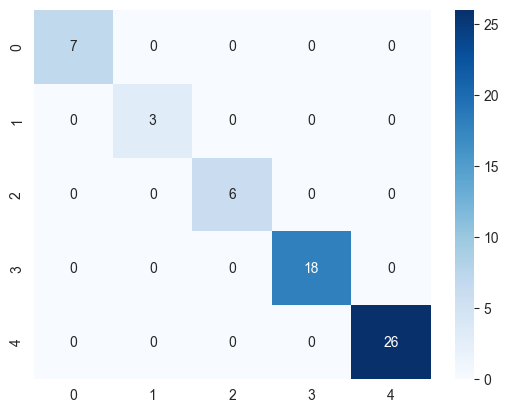

In [30]:
sns.heatmap(confusion_matrix(y_test, predictions), fmt = 'd', annot = True, cmap = 'Blues')